In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [7]:
train_data = np.load('Data+Description\\fashion_train.npy')
test_data = np.load('Data+Description\\fashion_test.npy')

In [ ]:
print(train_data)
print(test_data)

In [ ]:
train_data_X=train_data[:,:-1]
train_data_y=train_data[:,-1]

test_data_X=test_data[:,:-1]
test_data_y=test_data[:,-1]


In [ ]:
for i in range(100):
    print(i,':', train_data_y[i])

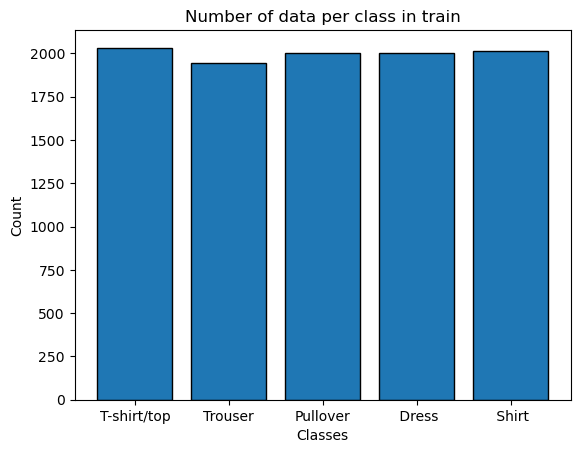

In [104]:
categories = ['T-shirt/top', 'Trouser', 'Pullover', ' Dress', ' Shirt']

# Plot the histogram
plt.hist(train_data_y, bins=np.arange(6)-0.5, edgecolor='black', rwidth=0.8)

# Set the x-ticks to the class names
plt.xticks(ticks=np.arange(5), labels=categories)

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('Number of data per class in train')

# Show the plot
plt.show()

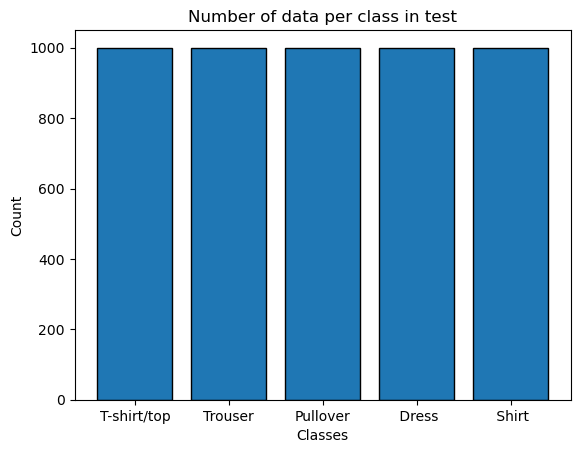

In [28]:
categories = ['T-shirt/top', 'Trouser', 'Pullover', ' Dress', ' Shirt']

# Plot the histogram
plt.hist(test_data_y, bins=np.arange(6)-0.5, edgecolor='black', rwidth=0.8)

# Set the x-ticks to the class names
plt.xticks(ticks=np.arange(5), labels=categories)

# Add labels and title
plt.xlabel('Classes')
plt.ylabel('Count')
plt.title('Number of data per class in test')

# Show the plot
plt.show()

[2033 1947 2001 2005 2014]


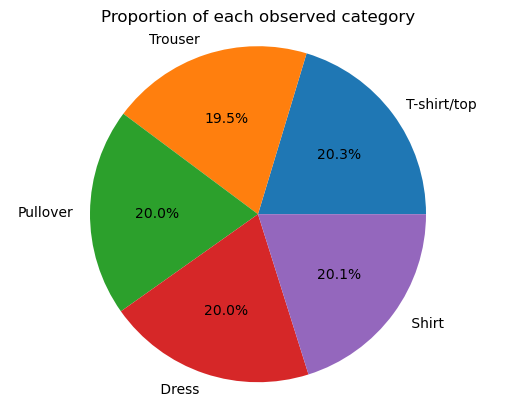

In [97]:
_, tc=np.unique(train_data_y, return_counts=True)
print(tc)
plt.pie(tc,
        explode=(0, 0, 0, 0, 0) , 
        labels=categories,
        autopct='%1.1f%%')
plt.axis('equal')
plt.title('Proportion of each observed category')
plt.show()

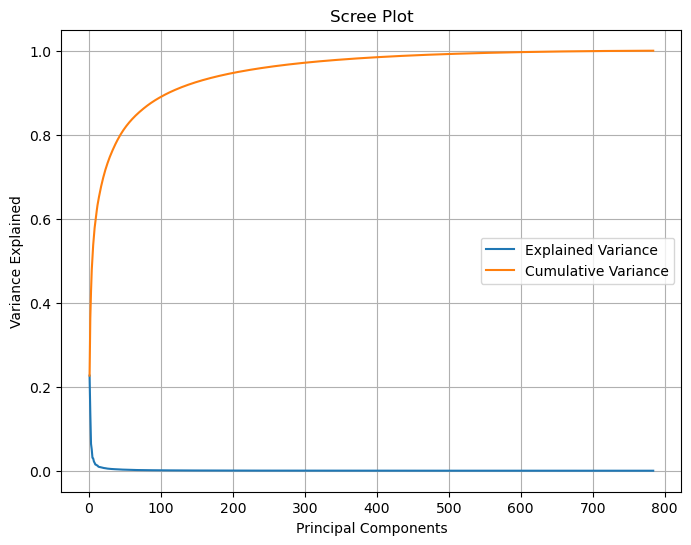

In [50]:
#PCA

scaler = StandardScaler()
image_scaled = scaler.fit_transform(train_data_X)

# Step 4: Apply PCA
pca = PCA()
pca.fit(image_scaled)

# Step 5: Scree plot - Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, label='Explained Variance')
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, label='Cumulative Variance')
plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.legend(loc='best')
plt.grid(True)
plt.show()

Напразни експерименти. Надолу има само мъка и човешко страдание.

In [100]:
print("Component | Cumulative Variance")
for i, var in enumerate(cumulative_variance):
    print(f"    {i+1}     |    {var:.4f}")
    

Component | Cumulative Variance
    1     |    0.2265
    2     |    0.3632
    3     |    0.4270
    4     |    0.4775
    5     |    0.5081
    6     |    0.5374
    7     |    0.5593
    8     |    0.5781
    9     |    0.5928
    10     |    0.6070
    11     |    0.6200
    12     |    0.6323
    13     |    0.6424
    14     |    0.6515
    15     |    0.6604
    16     |    0.6688
    17     |    0.6768
    18     |    0.6842
    19     |    0.6914
    20     |    0.6982
    21     |    0.7046
    22     |    0.7108
    23     |    0.7168
    24     |    0.7223
    25     |    0.7276
    26     |    0.7326
    27     |    0.7375
    28     |    0.7423
    29     |    0.7468
    30     |    0.7510
    31     |    0.7552
    32     |    0.7593
    33     |    0.7632
    34     |    0.7671
    35     |    0.7709
    36     |    0.7745
    37     |    0.7781
    38     |    0.7816
    39     |    0.7849
    40     |    0.7882
    41     |    0.7913
    42     |    0.7945
    43     

In [144]:
images=np.array([[train_data_X[0],train_data_X[2],train_data_X[14],train_data_X[18]], #T-shirts/tops
                 [train_data_X[1],train_data_X[5],train_data_X[9],train_data_X[13]], #Trousers
                 [train_data_X[6],train_data_X[7],train_data_X[8],train_data_X[17]], #Pullovers
                 [train_data_X[3],train_data_X[10],train_data_X[12],train_data_X[15]], #Dresses
                 [train_data_X[4],train_data_X[11],train_data_X[19],train_data_X[24]]]) #Shirts
#images[4,2]


In [138]:
images=np.array([train_data_X[0], #T-shirts/tops
                 train_data_X[1], #Trousers
                 train_data_X[6], #Pullovers
                 train_data_X[3], #Dresses
                 train_data_X[4]]) #Shirts
images[4,2]

0

In [ ]:
scaler = StandardScaler()

cumulative_variance_list = [0.60, 0.81, 0.89, 0.96, 1]
components_list = [10, 50, 100, 250, 784]
fig, axes = plt.subplots(len(cumulative_variance_list), 5, figsize=(15, 15))

for i, n_components in enumerate(cumulative_variance_list):
    # Reduce dimensions with the given number of components
    pca_n = PCA(n_components=n_components)
    
    # Plot the reconstructed image
    for j in range(5):
        images[j]=scaler.fit_transform(images[j])#.reshape(1, -1))
        reduced_image = pca_n.fit_transform(images[j])#.reshape(1, -1))
        print(reduced_image)
        print("!", j)
        # Reconstruct the image from the reduced components
        reconstructed_image = pca_n.inverse_transform(reduced_image)
        
        # Rescale back to original range
        reconstructed_image_rescaled = scaler.inverse_transform(reconstructed_image)

        # Reshape back to original image shape
        image_reconstructed = reconstructed_image_rescaled.reshape(56,56)
            
        ax = axes[i,j]
        ax.imshow(image_reconstructed, cmap='gray')
        ax.set_title(f"{components_list[i]} components")
        ax.axis('off')
    print("!!!", n_components)
# Show the plots
plt.tight_layout()
plt.show()

In [89]:

# Step 3: Standardize the flattened image
scaler = StandardScaler()
flattened_image_scaled = scaler.fit_transform(train_data_X[0].reshape(28,28))

# Step 4: Apply PCA and store results for different components
pca = PCA()
pca.fit(flattened_image_scaled)

# Choose different numbers of principal components to display
components_list = [10, 50, 100, 200, flattened_image_scaled.shape[1]]  # Include full PCA as well

# Create subplots to show reconstructed images
fig, axes = plt.subplots(1, len(components_list), figsize=(15, 5))

for i, n_components in enumerate(components_list):
    # Reduce dimensions with the given number of components
    pca_n = PCA(n_components=n_components)
    reduced_image = pca_n.fit_transform(flattened_image_scaled)
    
    # Reconstruct the image from the reduced components
    reconstructed_image = pca_n.inverse_transform(reduced_image)
    
    # Rescale back to original range
    reconstructed_image_rescaled = scaler.inverse_transform(reconstructed_image)
    
    # Reshape back to original image shape
    image_reconstructed = reconstructed_image_rescaled.reshape(original_shape)
    
    # Plot the reconstructed image
    ax = axes[i]
    ax.imshow(image_reconstructed, cmap='gray')
    ax.set_title(f"{n_components} components")
    ax.axis('off')

# Show the plots
plt.tight_layout()
plt.show()

ValueError: Expected 2D array, got 1D array instead:
array=[  0.   0.   0.   0.   0.   3.   0.   0.   0.  41.  92. 172. 100.  23.
  22.  33. 104. 136.  93.  44.   0.   0.   0.   2.   0.   0.   0.   0.
   0.   0.   0.   0.   2.   0.   6. 119. 166. 177. 159. 153. 227. 232.
 215. 240. 227. 156. 162. 180. 175. 102.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   2.   0.  16. 166. 143. 133. 126. 134. 121. 102. 146.
 171. 160. 106. 113. 130. 130. 136. 151. 159.   0.   0.   1.   0.   0.
   0.   0.   0.   1.   0. 105. 139. 123. 130. 129. 133. 133. 134. 116.
 108. 113. 129. 135. 136. 131. 128. 126. 150.  77.   0.   2.   0.   0.
   0.   0.   0.   0.   2. 151. 128. 126. 129. 130. 131. 130. 129. 131.
 135. 134. 130. 130. 131. 130. 130. 130. 139. 138.   0.   0.   0.   0.
   0.   0.   0.   0.  44. 148. 129. 126. 130. 133. 129. 129. 130. 130.
 129. 129. 130. 129. 131. 130. 131. 125. 146. 165.   2.   0.   0.   0.
   0.   0.   0.   0.  93. 156. 148. 124. 126. 126. 128. 128. 129. 129.
 129. 129. 129. 12